In [2]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
config.update('jax_enable_x64', True)
numpyro.set_platform('cpu')
num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

# jax device count: 4


In [3]:
import importlib_resources
from jnkepler.jaxttv.infer import *
from jnkepler.nbodytransit import *


In [4]:
import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
plt.rcParams["figure.figsize"] = (12,6)
from matplotlib import rc

# Load data

In [5]:
d = pd.read_csv("data_1339/toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
# d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

print(d)

     Planet_num  Index           Tc    Tc_err
0             1      0  1715.354632  0.001001
1             1      2  1733.115272  0.002002
2             1      3  1741.996592  0.001416
3             1      5  1759.759235  0.002002
4             1      6  1768.637553  0.003609
..          ...    ...          ...       ...
106           3     42  3354.302036  0.002238
107           3     43  3392.660442  0.001014
108           3     47  3546.074046  0.001416
109           3     49  3622.769837  0.002238
110           3     50  3661.127242  0.001533

[111 rows x 4 columns]


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_44390/1082065755.py:1: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("data_1339/toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [6]:
tcobs = [jnp.array(d.Tc[d.Planet_num==j+1]) for j in range(3)]
errorobs = [jnp.array(d.Tc_err[d.Planet_num==j+1]) for j in range(3)]
p_init = [8.88020257, 28.58140011, 38.35180318]

# tcobs = [jnp.array(d.Tc[d.Planet_num==j+2]) for j in range(2)]
# errorobs = [jnp.array(d.Tc_err[d.Planet_num==j+2]) for j in range(2)]
# p_init = [28.579657965796578, 38.35013501350135]

t_start = 1715.  # start of integration
t_end = 3670.
dt = 0.1 # integration timestep

In [7]:
print(tcobs)
print(errorobs)

[Array([1715.3546315, 1733.1152715, 1741.9965925, 1759.7592345,
       1768.6375525, 1786.3991935, 1795.2835175, 1804.1588325,
       1813.0421555, 1821.9184715, 1830.8017945, 1839.6811135,
       1875.2013925, 1892.9630335, 1901.8433535, 1910.7226725,
       1919.6019915, 1964.0035915, 1972.8839115, 1981.7652325,
       1990.6445515, 1999.5248715, 2008.4051915, 2425.7812325,
       2434.6625535, 2443.5428735, 2621.1512755, 2630.0275915,
       2647.7892325, 2656.6685515, 2701.0721535, 2718.8327935,
       2727.7111115, 2736.5914315, 2798.7546725, 2807.6349925,
       2816.5143115, 2825.3956325, 2834.2769535, 2843.1562725,
       2852.0375935, 2914.1968305, 2923.0781515, 2931.9574705,
       2940.8397925, 2949.7201125, 2958.6014335, 3296.0505905,
       3340.4541925, 3349.3345125, 3358.2128305, 3367.0961535,
       3375.9744715, 3384.8537905, 3393.7381145, 3402.6174335,
       3420.3750705, 3438.1377125, 3447.0180325, 3455.8983525,
       3464.7786725, 3473.6619955, 3535.8242355, 3544.

In [11]:
# detrended light curves around transits; here simultaneous transit is excluded
dlc = pd.read_csv("TOI1339_lc_photodyn.csv")
time_obs = jnp.array(dlc['time'])
flux_obs = jnp.array(dlc['flux']) - 1.  # normalize around 0
error_obs = jnp.array(dlc['flux_err'])

# Get the sorting indices
sort_idx = np.argsort(time_obs)

# Apply the same reordering to all arrays
time_obs = time_obs[sort_idx]
flux_obs = flux_obs[sort_idx]
error_obs = error_obs[sort_idx]
print(time_obs)
print(dlc)

[1711.36577373 1711.36716265 1711.36855156 ... 3662.82669654 3662.82692802
 3662.8271595 ]
                time      flux  flux_err
0        1790.657779  0.999069  0.000578
1        1790.659168  0.999941  0.000580
2        1790.660557  0.999068  0.000580
3        1790.661946  0.999770  0.000579
4        1790.663335  0.999724  0.000579
...              ...       ...       ...
1954365  3662.826234  0.998714  0.000903
1954366  3662.826465  0.998010  0.000903
1954367  3662.826697  1.001218  0.000904
1954368  3662.826928  0.998057  0.000903
1954369  3662.827159  1.000882  0.000905

[1954370 rows x 3 columns]


In [12]:
window = 0.25  # days
time_segments, flux_segments, error_segments = [], [], []

for planet_idx, tplanet in enumerate(tcobs):
    for t0 in tplanet:
        mask = (time_obs > t0 - window) & (time_obs < t0 + window)
        time_segments.append(time_obs[mask])
        flux_segments.append(flux_obs[mask])
        error_segments.append(error_obs[mask])

# Concatenate segments
time_obs_trim = np.concatenate(time_segments)
flux_obs_trim = np.concatenate(flux_segments)
error_obs_trim = np.concatenate(error_segments)

time_obs = jnp.array(time_obs_trim)
flux_obs = jnp.array(flux_obs_trim)
error_obs = jnp.array(error_obs_trim)

# Initialize

In [13]:
nt = NbodyTransit(t_start, t_end, dt, tcobs, p_init, errorobs=errorobs, print_info=True)
# nt.set_lcobs(time_obs)
nt.set_lcobs(time_obs, exposure_time=2/1440.)

# number of transiting planets:    3
# integration starts at:           1715.00
# first transit time in data:      1715.35
# last transit time in data:       3661.13
# integration ends at:             3670.00
# integration time step:           0.1000 (1/88 of innermost period)

# exposure time (min):             2.0
# supersampling factor:            10


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/nbodytransit/nbodytransit.py:72: UserWarning: set overlapping_transit to True if overlapping transits are present in the data.
  warnings.warn(


In [14]:
print(nt.times_lc)  # should be a JAX array of times
print(time_obs.shape, flux_obs.shape, error_obs.shape)
print([x.shape for x in tcobs])

[1715.10471746 1715.10610637 1715.10749528 ... 3661.37672554 3661.37695702
 3661.3771885 ]
(172241,) (172241,) (172241,)
[(72,), (22,), (17,)]


# TTV only optimization

In [15]:
param_bounds_ttv = ttv_default_parameter_bounds(nt, emax=0.5)

/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/infer.py:97: UserWarning: Bounds for cosi/lnode not provided: assuming coplanar orbits.
  warnings.warn(


# running least squares optimization...
# objective function: 173.33 --> 173.07 (111 data)
# elapsed time: 12.3 sec
{'period': array([ 8.88020225, 28.58138269, 38.35182213]), 'ecosw': array([ 0.16081647, -0.10667435, -0.0933825 ]), 'esinw': array([ 0.10343661, -0.04770153, -0.04089471]), 'tic': array([1715.35545272, 1726.05459054, 1743.55711739]), 'lnpmass': array([-10.92083576, -11.35697839, -11.88941669]), 'pmass': Array([1.80776217e-05, 1.16876435e-05, 6.86265142e-06], dtype=float64)}


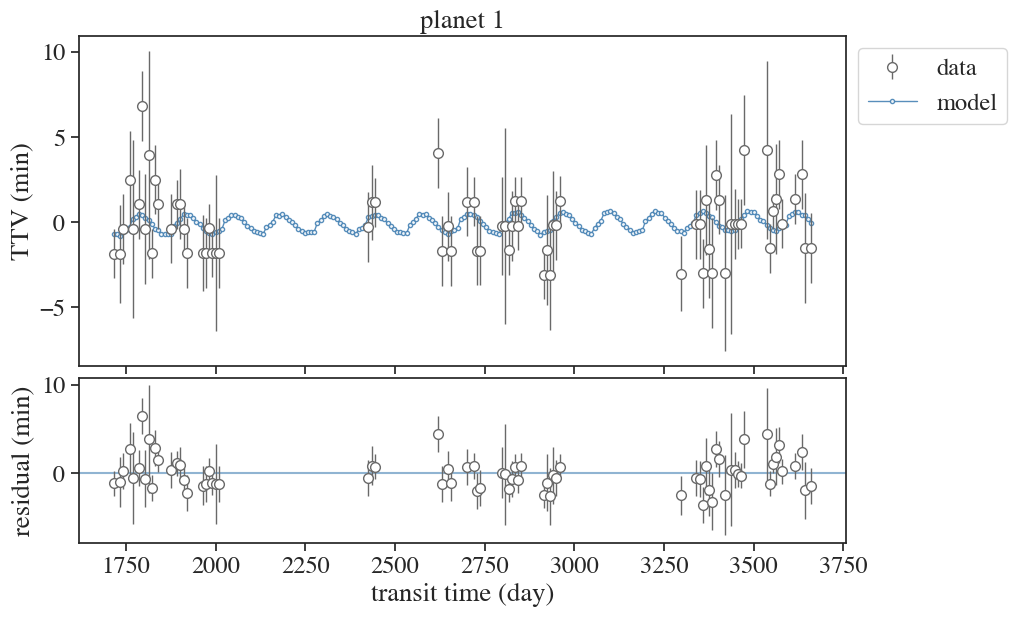

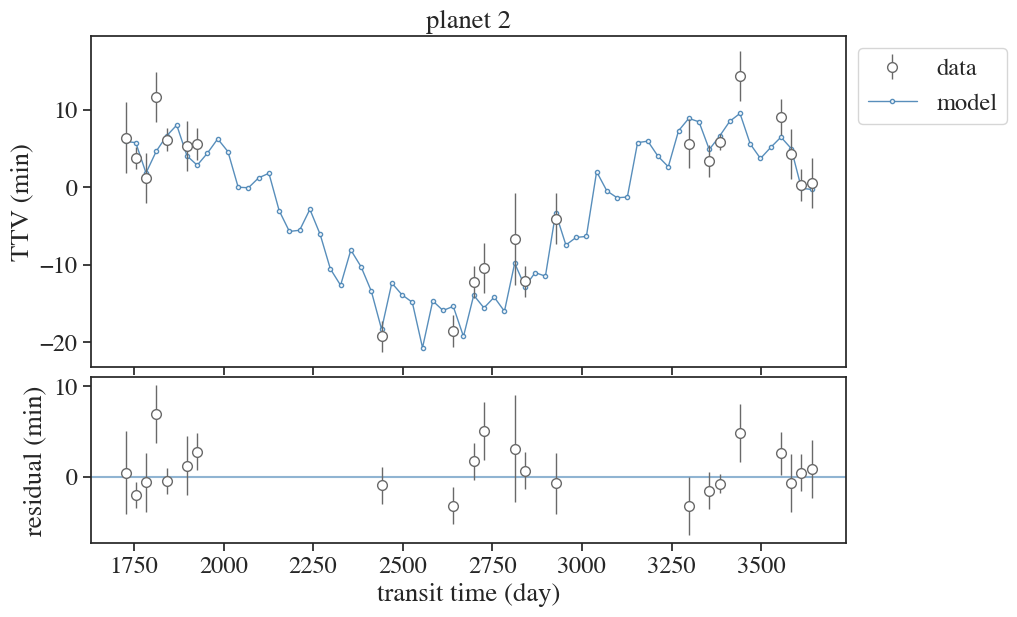

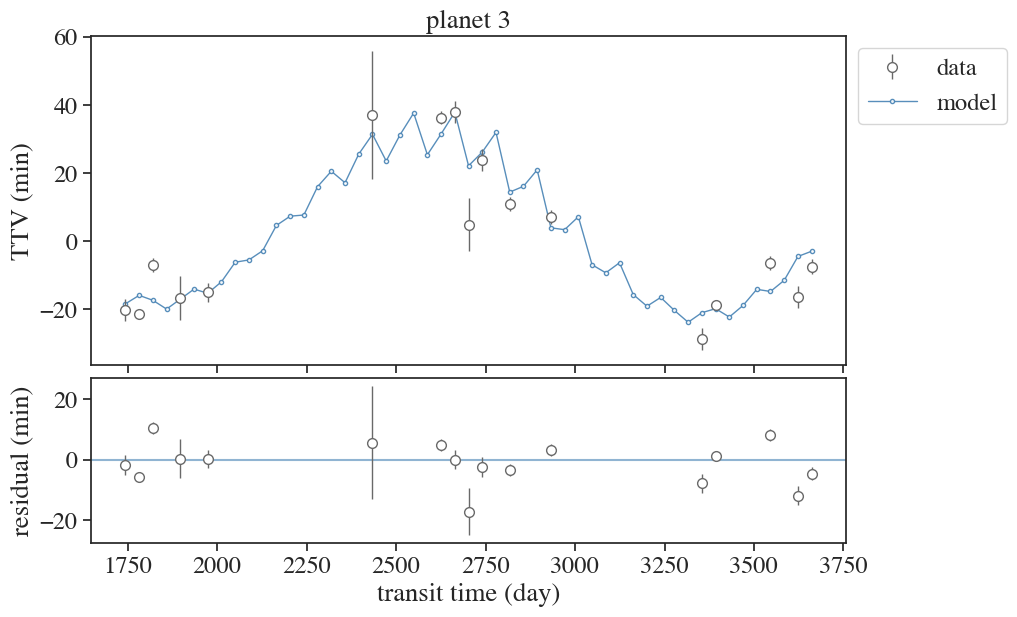

In [17]:
# p_init = np.array([8.87594849, 28.579657965796578, 38.35013501350135, 
#                    0.0, 0.05, 0.05, 
#                    0.0, 0.05, 0.05, 
#                    1715.3049092, 1726.05430737, 1743.55228223, 
#                    -10.41341358, -10.92425031, -11.61737528])

p_init = np.array([8.88020257, 28.58140011, 38.35180318,
                   0.16996202, -0.09855112, -0.0863744,
                   0.09494596, -0.04802669, -0.04114657,
                   1715.3554624, 1726.054591, 1743.55713087,
                   -10.90254937, -11.3564078 , -11.88909652,

    
])

# p_init = np.array([28.579657965796578, 38.35013501350135, 
#                    -0.21369753, -0.18361236, 
#                    -0.23016884, -0.19734158, 
#                    1726.05430737, 1743.55228223, 
#                    -10.97106092, -11.30491702])

popt = ttv_optim_curve_fit(nt, param_bounds_ttv, p_init=p_init)
print(popt)

In [19]:
import pickle 
with open('mcmc_runs/1339_jnkep_initial_fit_data_photodyn.pkl', 'wb') as f:
    pickle.dump({'jttv': nt, 'popt': popt, 'param_bounds': param_bounds_ttv}, f)

print('Initial fit data saved successfully')

Initial fit data saved successfully


# Transit parameter optimization

In [20]:
from jnkepler.infer import optim_svi

In [21]:
popt["smass"] = 0.81

In [22]:
keys_ttv = ["ecosw", "esinw", "pmass", "period", "tic"]
keys_transit = ["radius_ratio", "b", "srad", "q1", "q2", "meanflux"]
param_bounds_transit = {
    "q1": [jnp.array(0), jnp.array(1.)],
    "q2": [jnp.array(0), jnp.array(1.)],
    "radius_ratio":  [jnp.zeros(3), jnp.ones(3)*0.07],
    "b": [jnp.zeros(3), jnp.ones(3)*0.99],
    "srad": [jnp.array(0.5), jnp.array(1.1)],
    "meanflux": [jnp.array(-1e-4), jnp.array(1e-4)]
}

In [23]:
import celerite2
from celerite2.jax import terms as jax_terms

def model_fix_ttv(par_dict, param_bounds_transit):
    par = {}

    for key in keys_ttv + ["smass"]:
        par[key] = par_dict[key]

    for key in keys_transit:
        if key in ["q1", "q2", "b"]:
            par[key] = numpyro.sample(key, dist.Uniform(param_bounds_transit[key][0], param_bounds_transit[key][1]))
        else:
            par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds_transit[key][0]*0, param_bounds_transit[key][0]*0+1.))
            par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds_transit[key][1] - param_bounds_transit[key][0]) + param_bounds_transit[key][0])

    
    fluxmodel, tcmodel = nt.get_flux(par)
    numpyro.deterministic("tcmodel", tcmodel)
    fluxmodel = numpyro.deterministic("fluxmodel", fluxmodel)    
    residual = numpyro.deterministic("residual", flux_obs - fluxmodel - par["meanflux"])
    numpyro.deterministic("normed_residual", residual / error_obs)
    
    # GP likelihood
    lna = numpyro.sample("lna", dist.Uniform(low=-14, high=-4))
    lnc = numpyro.sample("lnc", dist.Uniform(low=-5, high=1))
    lnjitter = numpyro.sample("lnjitter", dist.Uniform(low=-14, high=-4))
    jitter = numpyro.deterministic("jitter", jnp.exp(lnjitter))
    kernel = jax_terms.Matern32Term(sigma=jnp.exp(lna), rho=jnp.exp(lnc))
    gp = celerite2.jax.GaussianProcess(kernel, mean=0.0)
    gp.compute(nt.times_lc, diag=error_obs**2 + jitter**2)
    numpyro.sample("obs", gp.numpyro_dist(), obs=residual)
    numpyro.deterministic("gppred", gp.predict(residual))

In [24]:
popt_transit = optim_svi(model_fix_ttv, 1e-2, 5000, p_initial=popt, par_dict=popt, param_bounds_transit=param_bounds_transit)


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jaxtyping/__init__.py:231: UserWarning: jaxtyping version >=0.2.23 should be used with Equinox version >=0.11.1
  warnings.warn(
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/infer.py:115: SyntaxWarning: invalid escape sequence '\m'
  label='normal, $\mathrm{SD}=%.2f$' % sd)
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/infer.py:117: SyntaxWarning: invalid escape sequence '\m'
  label='normal, $\mathrm{SD}=1$')
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/infer.py:126: SyntaxWarning: invalid escape sequence '\m'
  label='normal, $\mathrm{SD}=%.2f$' % sd)
/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/infer.py:128: SyntaxWarning: invalid escape sequence '\m'
  label='normal, $\mathrm{SD}=1$')


RuntimeError: Cannot find valid initial parameters. Please check your model again.

In [ ]:
from scipy.stats import norm 
def check_residuals(p):
    bins = np.linspace(-7, 7, 100)
    plt.yscale("log")
    plt.xlabel("normalized residual from GP mean")
    res = (p['residual'] - p["gppred"]) / error_obs
    plt.hist(res, bins=bins, density=True, alpha=0.6, label="SD=%.2f"%np.std(res))
    plt.ylim(plt.gca().get_ylim())
    plt.plot(bins, norm.pdf(bins), color='gray', label='standard normal')
    plt.legend(loc='best')
    plt.ylabel("PDF");

In [ ]:
check_residuals(popt_transit)

In [ ]:
# import jax, numpyro, celerite2
# print(jax.__version__)
# print(numpyro.__version__)
# print(celerite2.__version__)